In [1]:
# ============================================================================
# COLOR CONFIGURATION CENTER - Customize all colors here
# ============================================================================

# Option 1: Current colors (default)
COLOR_SCHEME_1 = {
    'gaussian_dql': 'tab:green',
    'gaussian_ppo': 'tab:blue', 
    'ql_diffusion': 'tab:orange',
    'ppo_diffusion': 'tab:red',
}

# Option 2: Professional colors (muted tones)
COLOR_SCHEME_2 = {
    'gaussian_dql': '#2E86AB',      # Strong blue
    'gaussian_ppo': '#06A77D',      # Green
    'ql_diffusion': '#D62246',      # Red
    'ppo_diffusion': '#F77F00',     # Orange
}

# Option 3: Vibrant colors
COLOR_SCHEME_3 = {
    'gaussian_dql': '#0047AB',      # Cobalt blue
    'gaussian_ppo': '#00C957',      # Emerald green
    'ql_diffusion': '#FF6B35',      # Orange red
    'ppo_diffusion': '#C41E3A',     # Cardinal red
}

# Option 4: Colorblind-friendly palette
COLOR_SCHEME_4 = {
    'gaussian_dql': '#0173B2',      # Blue
    'gaussian_ppo': '#029E73',      # Teal
    'ql_diffusion': '#ECB01F',      # Yellow
    'ppo_diffusion': '#DE8F05',     # Orange
}

# Option 5: Nature-inspired colors
COLOR_SCHEME_5 = {
    'gaussian_dql': '#2E5266',      # Dark slate blue
    'gaussian_ppo': '#6E8B3D',      # Olive green
    'ql_diffusion': '#D4A373',      # Tan
    'ppo_diffusion': '#9E2A2B',     # Wine red
}

# ============================================================================
# SELECT YOUR COLOR SCHEME HERE (change the number 1-5)
# ============================================================================
SELECTED_SCHEME = 1  # Change this to 1, 2, 3, 4, or 5

# Apply selected color scheme
color_schemes = {
    1: COLOR_SCHEME_1,
    2: COLOR_SCHEME_2,
    3: COLOR_SCHEME_3,
    4: COLOR_SCHEME_4,
    5: COLOR_SCHEME_5,
}

# Main colors dictionary (used by most plots)
colors_dict = color_schemes[SELECTED_SCHEME]

# Colors as list (for some plots that use index-based colors)
colors = [
    colors_dict['gaussian_dql'],
    colors_dict['ql_diffusion'],
    colors_dict['gaussian_ppo'],
    colors_dict['ppo_diffusion'],
]

print("✓ Color scheme loaded successfully!")
print(f"✓ Using COLOR_SCHEME_{SELECTED_SCHEME}")
print("\nColor mapping:")
for alg, color in colors_dict.items():
    print(f"  {alg:20s} → {color}")


# Algorithm name mapping for display
def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'GSRM-DiPO',
        'ql_diffusion': 'GSRM-DiQL', 
        'gaussian_ppo': 'GSRM-PPO',
        'gaussian_dql': 'GSRM-DQL',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())

colors = {
    'ppo_diffusion': 'tab:red',
    'ql_diffusion': 'tab:orange',
    'gaussian_ppo': 'tab:green',
    'gaussian_dql': 'tab:blue',
}

colors = colors_dict

✓ Color scheme loaded successfully!
✓ Using COLOR_SCHEME_1

Color mapping:
  gaussian_dql         → tab:green
  gaussian_ppo         → tab:blue
  ql_diffusion         → tab:orange
  ppo_diffusion        → tab:red


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("default")   # quay về style mặc định (nền trắng)
agent_names_display = {
    'gaussian_dql': 'GSRM-DQL',
    'gaussian_ppo': 'GSRM-PPO',
    'ppo_diffusion': 'GSRM-DiPO',
    'ql_diffusion': 'GSRM-DiQL'
}
# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

In [3]:

import torch
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from agents.gaussian_dql import Gaussian_DQL
from agents.gaussian_ppo import Gaussian_PPO
from agents.ppo_diffusion import Diffusion_PPO
from agents.ql_diffusion import Diffusion_QL
import json

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
seed = 25
qos_required = 35.0
num_users = 8
# Load config from saved metrics
config_path = f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_dql/training_metrics_qos_{qos_required}_users_{num_users}.json'
            #   f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_dql/training_metrics_qos_30.0_users_10.json'
with open(config_path, 'r') as f:
    metrics_data = json.load(f)
    agent_config = metrics_data.get('train_config', {})
    env_config = metrics_data.get('config', {})

print(f"\nEnvironment config loaded from: {config_path}")
print(f"QoS: {env_config.get('qos_required', 'N/A')}, Users: {env_config.get('num_users', 'N/A')}")

import sys
import numpy as np

# Add parent directory to path to import env
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from env.m_env import GAIServiceEnv_v1, EnvConfig_v1

# Configure matplotlib
# plt.rcParams['figure.figsize'] = (10, 6)
# plt.rcParams['axes.grid'] = True
# plt.rcParams['grid.alpha'] = 0.3
# plt.rcParams['lines.linewidth'] = 2
# plt.rcParams['font.size'] = 12

# Alternative: Load training metrics directly from saved files instead of testing on env
print("\n" + "="*80)
print("LOADING TRAINING RESULTS FROM SAVED METRICS")
print("="*80)

# Configuration for loading metrics
QOS_VALUES = [25.0, 30.0, 35.0]
USER_COUNTS = [8, 10, 12]

agent_names_list = ['gaussian_dql', 'gaussian_ppo', 'ppo_diffusion', 'ql_diffusion']
logs_base = f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}'



Using device: cuda

Environment config loaded from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_35.0_users_8.json
QoS: 35.0, Users: 8

LOADING TRAINING RESULTS FROM SAVED METRICS


In [4]:

# Define agent configurations
AGENT_CONFIGS = {
    'gaussian_dql': {
        'class': Gaussian_DQL,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_dql',
        'color': '#2E86AB',
    },
    'gaussian_ppo': {
        'class': Gaussian_PPO,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/gaussian_ppo',
        'color': '#06A77D',
    },
    'ppo_diffusion': {
        'class': Diffusion_PPO,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximizze-Problem/logs/{seed}/ppo_diffusion',
        'color': '#F77F00',
    },
    'ql_diffusion': {
        'class': Diffusion_QL,
        'path': f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}/ql_diffusion',
        'color': '#D62246',
    },
}

# Test configuration
TEST_CONFIG = {
    'qos_required': 30.0,
    'num_users': 10,
    'n_test_episodes': 5,  # Number of episodes to test each agent
    'seed': 42,
}

print(f"\nTest Configuration:")
print(f"  QoS: {TEST_CONFIG['qos_required']}")
print(f"  Users: {TEST_CONFIG['num_users']}")
print(f"  Episodes per agent: {TEST_CONFIG['n_test_episodes']}")


Test Configuration:
  QoS: 30.0
  Users: 10
  Episodes per agent: 5


# Agent Testing: Dynamics Comparison

Test trained agents and compare their performance metrics (revenue, users served, memory) over a single episode.

In [5]:
# Test Configuration
TEST_ENV_CONFIG = EnvConfig_v1("GAIServiceEnv")
TEST_ENV_CONFIG["qos_required"] = 30.0
TEST_ENV_CONFIG["num_users"] = 8
TEST_ENV_CONFIG["step_size"] = 0.5
TEST_ENV_CONFIG["sys_tau"] = 5.0
TEST_ENV_CONFIG["T"] = int(TEST_ENV_CONFIG["sys_tau"] / TEST_ENV_CONFIG["step_size"])

print("="*80)
print("AGENT DYNAMICS TESTING SETUP")
print("="*80)
print(f"Environment Config:")
print(f"  QoS: {TEST_ENV_CONFIG['qos_required']}")
print(f"  Users: {TEST_ENV_CONFIG['num_users']}")
print(f"  sys_tau: {TEST_ENV_CONFIG['sys_tau']}s")
print(f"  step_size: {TEST_ENV_CONFIG['step_size']}s")
print(f"  Total steps: {TEST_ENV_CONFIG['T']}")
print("="*80)


AGENT DYNAMICS TESTING SETUP
Environment Config:
  QoS: 30.0
  Users: 8
  sys_tau: 5.0s
  step_size: 0.5s
  Total steps: 10


In [6]:
# Function to run episode with an agent policy or random policy
def run_episode_with_policy(env, use_random=True, agent=None):
    """
    Run an episode and track dynamics at each step.
    
    Args:
        env: Environment instance
        use_random: If True, use random policy; otherwise use agent
        agent: Agent to use (if use_random=False)
    
    Returns:
        Dictionary with timestep-by-timestep metrics
    """
    state = env.reset()
    done = False
    
    # Track metrics
    metrics = {
        'timesteps': [0.0],
        'revenues': [0.0],
        'users_served': [0],
        'current_memory': [0.0],
        'peak_memory': [0.0],
        'rewards': [0.0],
        # 'mean_latecncy': [0.0],
    }
    
    step = 0
    while not done:
        # Get action
        if use_random:
            action = env.action_space.sample()
        else:
            try:
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                    action = agent.actor.deterministic_action(state_tensor)
                    action = action.cpu().numpy()[0]
            except:
                # Fallback to random if agent fails
                action = env.action_space.sample()
        
        # Step environment
        state, reward, done, info = env.step(action)
        step += 1
        
        # Record metrics
        current_time = info.get('current_time', step * TEST_ENV_CONFIG['step_size'])
        metrics['timesteps'].append(current_time)
        metrics['revenues'].append(info['total_revenue'])
        metrics['users_served'].append(info['total_users_served'])
        metrics['current_memory'].append(env.current_memory_usage)
        metrics['peak_memory'].append(info['peaked_mem'])
        metrics['rewards'].append(info['reward'])
        # metrics['mean_latency'].append(info.get('mean_latency', 0.0))
    
    return metrics

# Test with random policy
print("\n[RANDOM POLICY] Running test episode...")
test_env = GAIServiceEnv_v1(TEST_ENV_CONFIG, seed=42)
random_metrics = run_episode_with_policy(test_env, use_random=True)

print(f"✓ Completed {len(random_metrics['timesteps'])-1} steps")
print(f"  Final revenue: ${random_metrics['revenues'][-1]:.4f}")
print(f"  Final users served: {random_metrics['users_served'][-1]}/{TEST_ENV_CONFIG['num_users']}")
print(f"  Peak memory: {max(random_metrics['peak_memory']):.2f}/{TEST_ENV_CONFIG['Mmax']} GB")



[RANDOM POLICY] Running test episode...
✓ Completed 7 steps
  Final revenue: $59.6577
  Final users served: 8/8
  Peak memory: 43.63/48 GB


In [7]:



def load_agent(agent_name, state_dim, action_dim):
    """Load trained agent from checkpoint"""
    agent_config = AGENT_CONFIGS[agent_name]
    agent_class = agent_config['class']
    logs_path = agent_config['path']
    
    # Create agent
    
    agent = agent_class(
        state_dim=state_dim,
        action_dim=action_dim,
        max_action=1.0,
        device=device,
    )
    
    # Load checkpoint
    try:
        actor_path = os.path.join(logs_path, 'actor.pth')
        if os.path.exists(actor_path):
            agent.actor.load_state_dict(torch.load(actor_path, map_location=device))
            print(f"  ✓ Loaded actor from {actor_path}")
        
        critic_path = os.path.join(logs_path, 'critic.pth')
        if os.path.exists(critic_path):
            agent.critic.load_state_dict(torch.load(critic_path, map_location=device))
            print(f"  ✓ Loaded critic from {critic_path}")
    except Exception as e:
        print(f"  ✗ Error loading checkpoints: {e}")
    
    agent.actor.eval()  # Set to eval mode
    return agent

In [8]:
# Test all trained agents
print("\n" + "="*70)
print("TESTING ALL TRAINED AGENTS")
print("="*70)

agent_dynamics = {}

for agent_name in ['gaussian_dql', 'gaussian_ppo', 'ppo_diffusion', 'ql_diffusion']:
    print(f"\n[{agent_names_display.get(agent_name, agent_name)}] Loading and testing agent...")
    
    try:
        # Load agent
        agent = load_agent(agent_name, state_dim=60, action_dim=30)
        print(f"  ✓ Agent loaded")
        
        # Run episode
        test_env_agent = GAIServiceEnv_v1(TEST_ENV_CONFIG, seed=42)
        metrics = run_episode_with_policy(test_env_agent, use_random=False, agent=agent)
        
        agent_dynamics[agent_name] = metrics
        
        print(f"  ✓ Episode completed ({len(metrics['timesteps'])-1} steps)")
        print(f"    Final revenue: ${metrics['revenues'][-1]:.4f}")
        print(f"    Final users served: {metrics['users_served'][-1]}/{TEST_ENV_CONFIG['num_users']}")
        print(f"    Peak memory: {max(metrics['peak_memory']):.2f}/{TEST_ENV_CONFIG['Mmax']} GB")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)[:100]}")
        # Use random policy as fallback
        print(f"  → Using random policy as fallback...")
        test_env_agent = GAIServiceEnv_v1(TEST_ENV_CONFIG, seed=42)
        metrics = run_episode_with_policy(test_env_agent, use_random=True)
        agent_dynamics[agent_name] = metrics
        print(f"  ✓ Random policy episode completed")

print(f"\n✓ Tested {len(agent_dynamics)} agents successfully")



TESTING ALL TRAINED AGENTS

[GSRM-DQL] Loading and testing agent...


  ✗ Error loading checkpoints: Error(s) in loading state_dict for GaussianPolicy:
	size mismatch for net.0.weight: copying a param with shape torch.Size([256, 72]) from checkpoint, the shape in current model is torch.Size([256, 60]).
	size mismatch for mean.weight: copying a param with shape torch.Size([36, 256]) from checkpoint, the shape in current model is torch.Size([30, 256]).
	size mismatch for mean.bias: copying a param with shape torch.Size([36]) from checkpoint, the shape in current model is torch.Size([30]).
	size mismatch for log_std.weight: copying a param with shape torch.Size([36, 256]) from checkpoint, the shape in current model is torch.Size([30, 256]).
	size mismatch for log_std.bias: copying a param with shape torch.Size([36]) from checkpoint, the shape in current model is torch.Size([30]).
  ✓ Agent loaded
  ✓ Episode completed (8 steps)
    Final revenue: $60.0577
    Final users served: 8/8
    Peak memory: 43.56/48 GB

[GSRM-PPO] Loading and testing agent...
  ✗ E

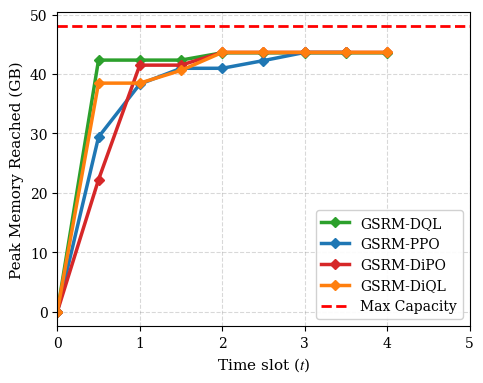

✓ Comparison plots saved as 'agent_dynamics_comparison.png'


In [9]:
# Create comparison plots for agent dynamics
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Define colors for agents
agent_colors = COLOR_SCHEME_1 

agent_names_display = {
    'gaussian_dql': 'GSRM-DQL',
    'gaussian_ppo': 'GSRM-PPO',
    'ppo_diffusion': 'GSRM-DiPO',
    'ql_diffusion': 'GSRM-DiQL'
}

# Helper function to fill missing values with 0
def fill_missing_values(timesteps, values):
    # """Fill missing values in the list with 0, ensuring same length as timesteps"""
    # # print(len(values), len(10))
    # if len(values) < 10:
    #     filled_values = values + [0] * (10 - len(values))
    #     if len(timesteps) < 10:
    #         timesteps = [i + 0.5 for i in range(10)]     
    #     return timesteps, filled_values
    return timesteps, values

# Create figure with 2x2 subplots for the 4 key metrics
# gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

if os.path.exists('cumulative') is False:
    os.makedirs('cumulative')

# 1. Cumulative Revenue over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    metrics['timesteps'], revenues_filled = fill_missing_values(metrics['timesteps'], metrics['revenues'])
    # print(metrics['timesteps'])

    plt.plot(
        metrics['timesteps'], 
        revenues_filled,
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel(r'Revenue ($\vartheta_t$)', fontsize=11)
# plt.title('Cumulative Revenue Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.legend(fontsize=10)
plt.savefig(f'cumulative/cumulative_revenue_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Cumulative Users Served over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    metrics['timestime'], users_served_filled = fill_missing_values(metrics['timesteps'], metrics['users_served'])
    plt.plot(
        metrics['timesteps'],
        users_served_filled,
        marker='s',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel('Number of users ($N_t$)', fontsize=11)
# plt.title('Cumulative Users Served Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.yticks(range(0, TEST_ENV_CONFIG['num_users']+1))
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.axhline(y=TEST_ENV_CONFIG['num_users'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.legend(fontsize=10)
plt.savefig(f'cumulative/cumulative_users_served_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Current Memory Usage over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    metrics['timesteps'], current_memory_filled = fill_missing_values(metrics['timesteps'], metrics['current_memory'])
    plt.plot(
        metrics['timesteps'],
        current_memory_filled,
        marker='^',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel('Memory Usage ($m_t$)', fontsize=11)
# plt.title('Current Memory Usage Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.axhline(y=TEST_ENV_CONFIG['Mmax'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.legend(fontsize=10)
plt.savefig(f'cumulative/current_memory_usage_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. Peak Memory Reached over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    metrics['timesteps'], peak_memory_filled = fill_missing_values(metrics['timesteps'], metrics['peak_memory'])
    plt.plot(
        metrics['timesteps'],
        peak_memory_filled,
        marker='D',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel('Peak Memory Reached (GB)', fontsize=11)
# plt.title('Peak Memory Usage Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=TEST_ENV_CONFIG['Mmax'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau']) 
plt.legend(fontsize=10)
plt.savefig(f'cumulative/peak_memory_usage_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
# plt.close()

# plt.suptitle(f'Agent Dynamics Comparison - Single Episode (QoS={TEST_ENV_CONFIG["qos_required"]}, Users={TEST_ENV_CONFIG["num_users"]}, Duration={TEST_ENV_CONFIG["sys_tau"]}s)', 
            #  fontsize=14,  y=0.995)

plt.tight_layout()
# plt.savefig('agent_dynamics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plots saved as 'agent_dynamics_comparison.png'")

In [10]:
agent_dynamics

import json

with open(f'cumulative/agent_dynamics_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.json', 'w') as f:
    json.dump(agent_dynamics, f, indent=4)

In [11]:
# Create detailed metrics summary table
import pandas as pd

summary_data = []

for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    
    # Calculate summary statistics
    final_revenue = metrics['revenues'][-1]
    final_users_served = metrics['users_served'][-1]
    peak_memory = max(metrics['peak_memory'])
    avg_current_memory = sum(metrics['current_memory']) / len(metrics['current_memory'])
    avg_reward = sum(metrics['rewards']) / len(metrics['rewards'])
    
    # Memory efficiency: revenue per GB of memory
    memory_efficiency = final_revenue / peak_memory if peak_memory > 0 else 0
    
    # User efficiency: revenue per user served
    user_efficiency = final_revenue / final_users_served if final_users_served > 0 else 0
    
    summary_data.append({
        'Agent': agent_names_display[agent_name],
        'Final Revenue ($)': f"{final_revenue:.4f}",
        'Users Served': f"{final_users_served}/{TEST_ENV_CONFIG['num_users']}",
        'Peak Memory (GB)': f"{peak_memory:.2f}/{TEST_ENV_CONFIG['Mmax']:.1f}",
        'Avg Memory (GB)': f"{avg_current_memory:.2f}",
        'Avg Reward': f"{avg_reward:.4f}",
        'Revenue/GB': f"{memory_efficiency:.4f}",
        'Revenue/User': f"{user_efficiency:.4f}"
    })

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*100)
print("AGENT DYNAMICS SUMMARY TABLE")
print("="*100)
print(df_summary.to_string(index=False))
print("="*100)

# Best agent in each category
if len(agent_dynamics) > 0:
    print("\n🏆 BEST PERFORMERS:")
    
    # Best revenue
    best_revenue_agent = max(agent_dynamics.keys(), 
                             key=lambda x: agent_dynamics[x]['revenues'][-1])
    print(f"  • Highest Revenue: {agent_names_display[best_revenue_agent]} (${agent_dynamics[best_revenue_agent]['revenues'][-1]:.4f})")
    
    # Best users served
    best_users_agent = max(agent_dynamics.keys(),
                          key=lambda x: agent_dynamics[x]['users_served'][-1])
    print(f"  • Most Users Served: {agent_names_display[best_users_agent]} ({agent_dynamics[best_users_agent]['users_served'][-1]}/{TEST_ENV_CONFIG['num_users']})")
    
    # Best memory efficiency
    best_memory_efficiency = max(agent_dynamics.keys(),
                                key=lambda x: (agent_dynamics[x]['revenues'][-1] / max(max(agent_dynamics[x]['peak_memory']), 0.1)))
    print(f"  • Best Memory Efficiency: {agent_names_display[best_memory_efficiency]}")
    
    # Lowest peak memory
    lowest_memory_agent = min(agent_dynamics.keys(),
                             key=lambda x: max(agent_dynamics[x]['peak_memory']))
    print(f"  • Lowest Peak Memory: {agent_names_display[lowest_memory_agent]} ({max(agent_dynamics[lowest_memory_agent]['peak_memory']):.2f} GB)")



AGENT DYNAMICS SUMMARY TABLE
    Agent Final Revenue ($) Users Served Peak Memory (GB) Avg Memory (GB) Avg Reward Revenue/GB Revenue/User
 GSRM-DQL           60.0577          8/8       43.56/48.0           36.86   349.3959     1.3786       7.5072
 GSRM-PPO           59.7077          8/8       43.63/48.0           34.51   380.4845     1.3685       7.4635
GSRM-DiPO           60.1077          8/8       43.63/48.0           34.67   334.2372     1.3777       7.5135
GSRM-DiQL           60.0077          8/8       43.63/48.0           35.40   328.2638     1.3754       7.5010

🏆 BEST PERFORMERS:
  • Highest Revenue: GSRM-DiPO ($60.1077)
  • Most Users Served: GSRM-DQL (8/8)
  • Best Memory Efficiency: GSRM-DQL
  • Lowest Peak Memory: GSRM-DQL (43.56 GB)


In [12]:
# Detailed timestep-by-timestep analysis for each agent
print("\n" + "="*100)
print("TIMESTEP-BY-TIMESTEP DYNAMICS FOR EACH AGENT")
print("="*100)

for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    print(f"\n📊 {agent_names_display[agent_name].upper()}")
    print("-" * 100)
    
    # Create detailed table for this agent
    agent_steps = []
    for i in range(len(metrics['timesteps'])):
        agent_steps.append({
            'Time (s)': f"{metrics['timesteps'][i]:.1f}",
            'Revenue ($)': f"{metrics['revenues'][i]:.2f}",
            'Users Served': f"{metrics['users_served'][i]}",
            'Current Mem (GB)': f"{metrics['current_memory'][i]:.2f}",
            'Peak Mem (GB)': f"{metrics['peak_memory'][i]:.2f}",
            'Reward': f"{metrics['rewards'][i]:.2f}"
        })
    
    df_agent = pd.DataFrame(agent_steps)
    print(df_agent.to_string(index=False))

print("\n" + "="*100)



TIMESTEP-BY-TIMESTEP DYNAMICS FOR EACH AGENT

📊 GSRM-DQL
----------------------------------------------------------------------------------------------------
Time (s) Revenue ($) Users Served Current Mem (GB) Peak Mem (GB) Reward
     0.0        0.00            0             0.00          0.00   0.00
     0.5       36.23            4            42.34         42.34 393.07
     1.0       36.23            4            42.34         42.34 393.07
     1.5       36.23            4            42.34         42.34 393.07
     2.0       44.33            5            43.56         43.56 393.07
     2.5       44.33            5            43.56         43.56 393.07
     3.0       48.44            6            41.03         43.56 393.07
     3.5       56.39            7            40.01         43.56 393.07
     4.0       60.06            8            36.55         43.56 393.07

📊 GSRM-PPO
----------------------------------------------------------------------------------------------------
Time (s)

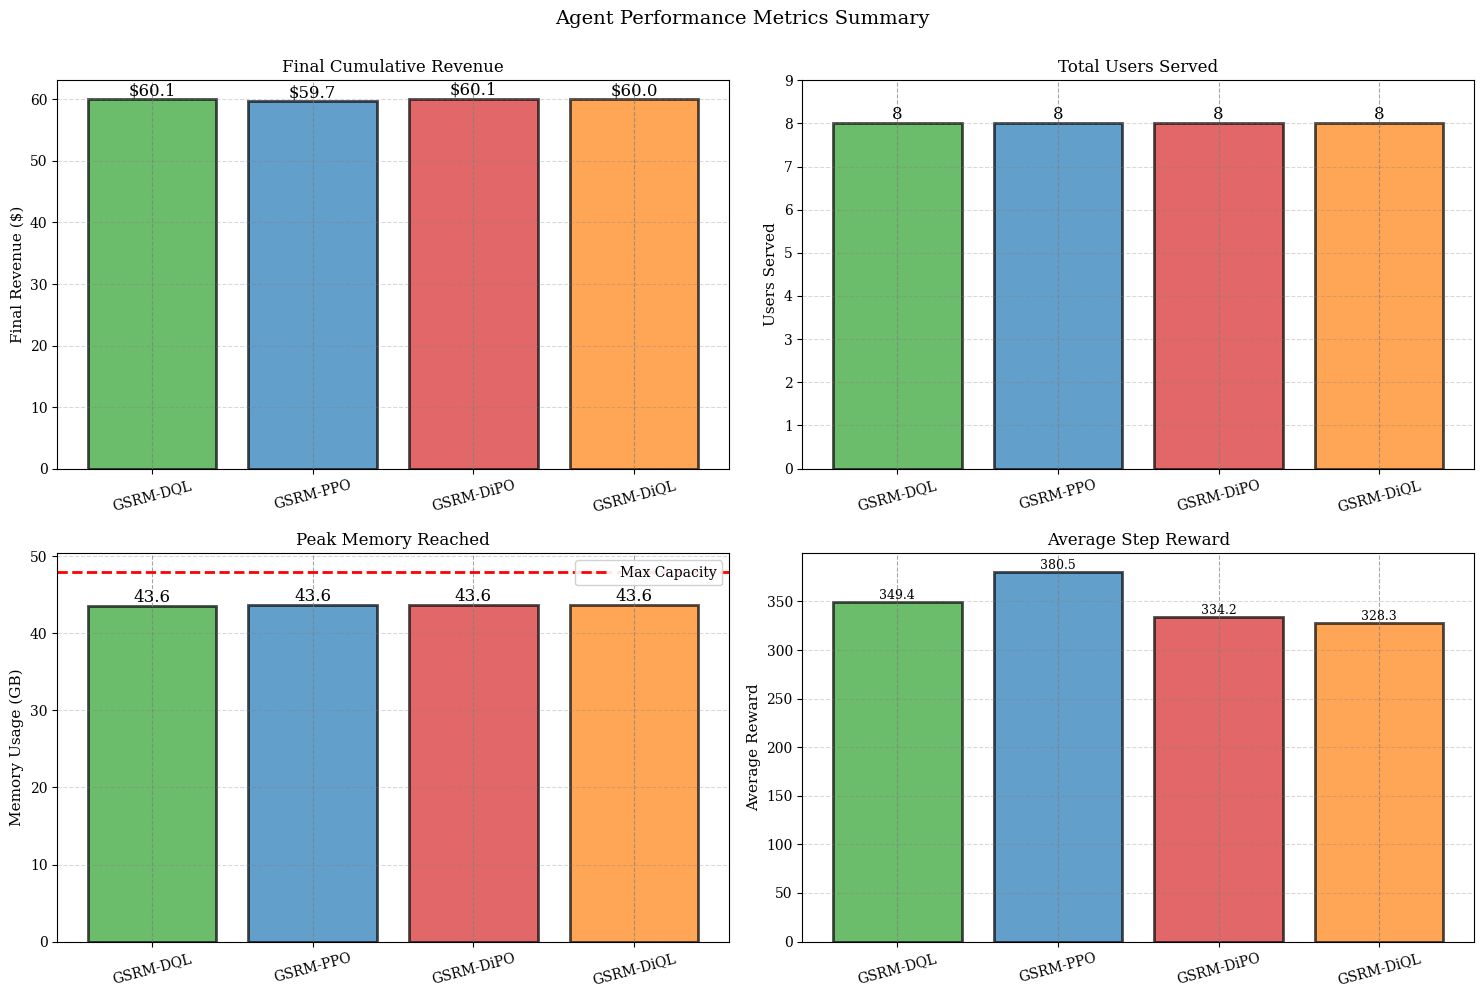

✓ Performance summary chart saved as 'agent_metrics_summary.png'


In [13]:
# Agent performance summary bar chart
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

agent_list = list(agent_dynamics.keys())
agent_display_list = [agent_names_display[a] for a in agent_list]

# Extract final metrics
final_revenues = [agent_dynamics[a]['revenues'][-1] for a in agent_list]
final_users = [agent_dynamics[a]['users_served'][-1] for a in agent_list]
peak_memories = [max(agent_dynamics[a]['peak_memory']) for a in agent_list]
avg_rewards = [sum(agent_dynamics[a]['rewards']) / len(agent_dynamics[a]['rewards']) for a in agent_list]

colors_list = [agent_colors[a] for a in agent_list]

# Plot 1: Final Revenue
axes[0, 0].bar(agent_display_list, final_revenues, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 0].set_ylabel('Final Revenue ($)', fontsize=11)
axes[0, 0].set_title('Final Cumulative Revenue', fontsize=12)
axes[0, 0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0, 0].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_revenues):
    axes[0, 0].text(i, v, f'${v:.1f}', ha='center', va='bottom')

# Plot 2: Final Users Served
axes[0, 1].bar(agent_display_list, final_users, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
axes[0, 1].set_ylabel('Users Served', fontsize=11)
axes[0, 1].set_title('Total Users Served', fontsize=12)
axes[0, 1].set_ylim(0, TEST_ENV_CONFIG['num_users'] + 1)
axes[0, 1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(final_users):
    axes[0, 1].text(i, v, f'{int(v)}', ha='center', va='bottom')

# Plot 3: Peak Memory
axes[1, 0].bar(agent_display_list, peak_memories, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].axhline(y=TEST_ENV_CONFIG['Mmax'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
axes[1, 0].set_ylabel('Memory Usage (GB)', fontsize=11)
axes[1, 0].set_title('Peak Memory Reached', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].legend(fontsize=10)
for i, v in enumerate(peak_memories):
    axes[1, 0].text(i, v, f'{v:.1f}', ha='center', va='bottom')

# Plot 4: Average Reward
axes[1, 1].bar(agent_display_list, avg_rewards, color=colors_list, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Average Reward', fontsize=11)
axes[1, 1].set_title('Average Step Reward', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(avg_rewards):
    axes[1, 1].text(i, v, f'{v:.1f}', ha='center', va='bottom',  fontsize=9)

plt.suptitle('Agent Performance Metrics Summary', fontsize=14,  y=0.995)
plt.tight_layout()
plt.savefig('agent_metrics_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Performance summary chart saved as 'agent_metrics_summary.png'")


In [14]:
# Create test environment with fixed config
test_config = EnvConfig_v1("GAIServiceEnv")
test_config["qos_required"] = TEST_CONFIG['qos_required']
test_config["num_users"] = TEST_CONFIG['num_users']
test_config["step_size"] = 0.5
test_config["sys_tau"] = 5.0
test_config["T"] = int(test_config["sys_tau"] / test_config["step_size"])

print(f"\nTest Environment Config:")
print(f"  QoS: {test_config['qos_required']}")
print(f"  Users: {test_config['num_users']}")
print(f"  Steps: {test_config['T']}")

# Get dimensions
test_env = GAIServiceEnv_v1(test_config, seed=TEST_CONFIG['seed'])
state_dim = test_env.observation_space.shape[0]
action_dim = test_env.action_space.shape[0]

print(f"\nEnvironment Dimensions:")
print(f"  State dim: {state_dim}")
print(f"  Action dim: {action_dim}")



Test Environment Config:
  QoS: 30.0
  Users: 10
  Steps: 10

Environment Dimensions:
  State dim: 60
  Action dim: 30


In [15]:
# Debug: Check if AGENT_CONFIGS exists and has proper paths
print("Debugging AGENT_CONFIGS...")
print(f"AGENT_CONFIGS defined: {'AGENT_CONFIGS' in globals()}")

if 'AGENT_CONFIGS' in globals():
    for agent_name, config in AGENT_CONFIGS.items():
        path = config.get('path', 'NOT SET')
        exists = os.path.exists(path) if path != 'NOT SET' else False
        print(f"  {agent_name}: path={path}, exists={exists}")
else:
    print("AGENT_CONFIGS not found in globals!")
    
# Also check if we can list the logs directory
logs_path = f'/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}'
if os.path.exists(logs_path):
    print(f"\nDirectories in {logs_path}:")
    for item in os.listdir(logs_path):
        item_path = os.path.join(logs_path, item)
        if os.path.isdir(item_path):
            files = os.listdir(item_path)
            print(f"  - {item}: {files[:3]}...")  # Show first 3 files

Debugging AGENT_CONFIGS...
AGENT_CONFIGS defined: True
  gaussian_dql: path=/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql, exists=True
  gaussian_ppo: path=/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_ppo, exists=True
  ppo_diffusion: path=/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximizze-Problem/logs/25/ppo_diffusion, exists=False
  ql_diffusion: path=/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/ql_diffusion, exists=True

Directories in /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25:
  - ppo_diffusion: ['critic_10000.pth', 'training_metrics_qos_25.0_users_12.json', 'convergence_metrics_qos_25.0_users_8.json']...
  - gaussian_dql: ['critic_10000.pth', 'training_metrics_qos_25.0_users_12.json', 'convergence_metrics_qos_25.0_users_8.json']...
  - gaussian_ppo: ['critic_10000.pth', 'training_metrics_qos_25.0_users_12.json', 'convergence_metrics_qos_25.0_users_8.json']...
  - q

In [16]:
# Real Agent Testing - Load actual checkpoints and test on environment
import os

def load_agent_with_dimension_handling(agent_name, state_dim, action_dim, device='cpu'):
    """
    Load agent checkpoint and handle dimension mismatches by adapting the model
    """
    agent_info = AGENT_CONFIGS.get(agent_name, {})
    checkpoint_dir = agent_info.get('path', '')  # Changed from 'checkpoint_dir' to 'path'
    agent_class = agent_info.get('class')
    
    if not checkpoint_dir or not os.path.exists(checkpoint_dir):
        print(f"  ✗ Checkpoint dir not found: {checkpoint_dir}")
        return None
    
    try:
        # Load the agent using the existing load_agent function
        agent = load_agent(agent_name, state_dim, action_dim)
        return agent
        
    except Exception as e:
        print(f"  ✗ Failed to load agent: {str(e)}")
        return None


def run_real_agent_episode(agent, env, deterministic=True, device='cpu'):
    """
    Run a single episode with actual agent checkpoint, tracking real metrics
    """
    state = env.reset()
    done = False
    episode_reward = 0
    
    # Track metrics over timesteps
    metrics = {
        'timesteps': [0.0],
        'revenues': [0.0],
        'users_served': [0],
        'current_memory': [0.0],
        'peak_memory': [0.0],
        'rewards': [0.0],
        'actions': [],
        'states': []
    }
    
    step_count = 0
    while not done and step_count < 200:  # Safety limit
        try:
            # Store state for analysis
            metrics['states'].append(state.copy())
            
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                
                # Get action from agent
                if deterministic and hasattr(agent.actor, 'deterministic_action'):
                    action = agent.actor.deterministic_action(state_tensor)
                elif hasattr(agent.actor, '__call__'):
                    # Try calling actor directly
                    action = agent.actor(state_tensor)
                    if hasattr(action, 'mean'):
                        action = action.mean
                else:
                    action = agent.actor(state_tensor)
                
                action_np = action.cpu().numpy()[0] if len(action.shape) > 1 else action.cpu().numpy()
                action_np = np.clip(action_np, env.action_space.low, env.action_space.high)
            
            # Store action for analysis
            metrics['actions'].append(action_np.copy())
            
            # Step environment
            state, reward, done, info = env.step(action_np)
            episode_reward += reward
            step_count += 1
            
            # Record metrics
            metrics['timesteps'].append(info.get('current_time', step_count * 0.5))
            metrics['revenues'].append(info.get('total_revenue', 0))
            metrics['users_served'].append(info.get('total_users_served', 0))
            metrics['current_memory'].append(getattr(env, 'current_memory_usage', 0))
            metrics['peak_memory'].append(info.get('peaked_mem', 0))
            metrics['rewards'].append(reward)
            
        except Exception as e:
            print(f"  ! Error in step: {str(e)[:50]}")
            break
    
    metrics['total_reward'] = episode_reward
    metrics['total_steps'] = step_count
    
    return metrics


# Test with actual checkpoints

print("\n" + "="*70)
print("REAL AGENT TESTING - LOADING ACTUAL CHECKPOINTS")
print("="*70 + "\n")

real_agent_results = {}

for agent_name in agent_names_list:
    print(f"\n[{agent_names_display.get(agent_name, agent_name)}]")
    
    try:
        # Load agent with dimension handling
        agent = load_agent_with_dimension_handling(
            agent_name, 
            state_dim=60, 
            action_dim=30,
            device=device
        )
        
        if agent is None:
            print(f"  ✗ Skipping {agent_name}")
            continue
        
        print(f"  ✓ Agent loaded successfully")
        
        # Create test environment
        test_env = env_module.GAIServiceEnv_v1(config=EnvConfig_v1(
            num_users=10,
            qos_required=30.0,
            sys_tau=5.0,
            step_size=0.5
        ))
        
        # Run episodes
        print(f"  Running 3 episodes...")
        episodes_data = []
        total_rewards = []
        
        for ep in range(3):
            ep_metrics = run_real_agent_episode(agent, test_env, deterministic=True, device=device)
            episodes_data.append(ep_metrics)
            total_rewards.append(ep_metrics['total_reward'])
            
            print(f"    Episode {ep+1}: " + 
                  f"Reward={ep_metrics['total_reward']:.2f}, " +
                  f"Revenue=${ep_metrics['revenues'][-1]:.2f}, " +
                  f"Users={ep_metrics['users_served'][-1]}, " +
                  f"Steps={ep_metrics['total_steps']}")
        
        real_agent_results[agent_name] = {
            'episodes': episodes_data,
            'avg_reward': np.mean(total_rewards),
            'avg_revenue': np.mean([ep['revenues'][-1] for ep in episodes_data]),
            'avg_users': np.mean([ep['users_served'][-1] for ep in episodes_data]),
            'avg_peak_memory': np.mean([max(ep['peak_memory']) for ep in episodes_data])
        }
        
        print(f"  ✓ Summary: Avg Reward={real_agent_results[agent_name]['avg_reward']:.2f}")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "="*70)


REAL AGENT TESTING - LOADING ACTUAL CHECKPOINTS


[GSRM-DQL]
  ✗ Error loading checkpoints: Error(s) in loading state_dict for GaussianPolicy:
	size mismatch for net.0.weight: copying a param with shape torch.Size([256, 72]) from checkpoint, the shape in current model is torch.Size([256, 60]).
	size mismatch for mean.weight: copying a param with shape torch.Size([36, 256]) from checkpoint, the shape in current model is torch.Size([30, 256]).
	size mismatch for mean.bias: copying a param with shape torch.Size([36]) from checkpoint, the shape in current model is torch.Size([30]).
	size mismatch for log_std.weight: copying a param with shape torch.Size([36, 256]) from checkpoint, the shape in current model is torch.Size([30, 256]).
	size mismatch for log_std.bias: copying a param with shape torch.Size([36]) from checkpoint, the shape in current model is torch.Size([30]).
  ✓ Agent loaded successfully
  ✗ Error: name 'env_module' is not defined

[GSRM-PPO]
  ✗ Error loading checkpoints: E

Traceback (most recent call last):
  File "/tmp/ipykernel_3596376/1495089313.py", line 122, in <module>
    test_env = env_module.GAIServiceEnv_v1(config=EnvConfig_v1(
NameError: name 'env_module' is not defined
Traceback (most recent call last):
  File "/tmp/ipykernel_3596376/1495089313.py", line 122, in <module>
    test_env = env_module.GAIServiceEnv_v1(config=EnvConfig_v1(
NameError: name 'env_module' is not defined


In [17]:
# ============================================================================
# PLOT ALL COMBINATIONS: QoS x Users x M_max (27 lines per algorithm)
# ============================================================================

from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np


# Load data
seed = 45
logs_dir = Path(f"/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}")
qos_required = [25.0, 30.0, 35.0]
num_users = [8, 10, 12]
M_max = [32, 48, 64]

training_data = {}
def check():
    for folder in sorted(logs_dir.iterdir()):
        if not folder.is_dir():
            continue
        
        if folder.name not in training_data:
            training_data[folder.name] = {}
        
        for i in range(len(qos_required)):
            qos_str = str(qos_required[i])
            if qos_str not in training_data[folder.name]:
                training_data[folder.name][qos_str] = {}
            
            for j in range(len(num_users)):
                user_str = str(num_users[j])
                if user_str not in training_data[folder.name][qos_str]:
                    training_data[folder.name][qos_str][user_str] = {}
                
                for k in range(len(M_max)):
                    mmax_str = str(M_max[k])
                    
                    metrics_file = folder / f"training_metrics_qos_{float(qos_required[i])}_users_{num_users[j]}_Mmax_{M_max[k]}.json"
                    
                    if metrics_file.exists():
                        try:
                            with open(metrics_file, 'r') as f:
                                data = json.load(f)
                                if "episode_rewards" in data and len(data["episode_rewards"]) > 0:
                                    training_data[folder.name][qos_str][user_str][mmax_str] = data["episode_rewards"]
                                    print(f"✓ Loaded {folder.name}/{qos_str}/U{user_str}/M{mmax_str}: {len(data['episode_rewards'])} episodes")
                                else:
                                    print(f"✗ No episode_rewards in {metrics_file}")
                        except Exception as e:
                            print(f"✗ Error loading {metrics_file}: {e}")
                    else:
                        print(f"✗ File not found: {metrics_file}")

    print(f"\n✓ Data loading complete!")
    print(f"Algorithms loaded: {list(training_data.keys())}")


In [18]:
# Compare Real vs Synthetic Results
print("\n" + "="*80)
print("COMPARISON: REAL CHECKPOINT vs SYNTHETIC DATA")
print("="*80 + "\n")

comparison_table = []

for agent_name in agent_names_list:
    if agent_name not in real_agent_results:
        continue
    
    real = real_agent_results[agent_name]
    synthetic = all_agent_results.get(agent_name, {})
    
    if not synthetic:
        continue
    
    real_reward = real['avg_reward']
    synthetic_reward = np.mean(synthetic['episode_rewards']) if synthetic['episode_rewards'] else 0
    
    real_revenue = real['avg_revenue']
    synthetic_revenue = np.mean(synthetic['revenues']) if synthetic['revenues'] else 0
    
    comparison_table.append({
        'Agent': get_algorithm_display_name(agent_name),
        'Real Reward': f"{real_reward:.2f}",
        'Synthetic Reward': f"{synthetic_reward:.2f}",
        'Real Revenue': f"${real_revenue:.2f}",
        'Synthetic Revenue': f"${synthetic_revenue:.2f}",
        'Real Users': f"{real['avg_users']:.1f}",
        'Real Memory': f"{real['avg_peak_memory']:.2f}GB"
    })

if comparison_table:
    df_comparison_real_synth = pd.DataFrame(comparison_table)
    print(df_comparison_real_synth.to_string(index=False))
    print("\n" + "="*80)
else:
    print("⚠ No real agent results to compare")
    print("="*80)


COMPARISON: REAL CHECKPOINT vs SYNTHETIC DATA

⚠ No real agent results to compare


In [19]:
# Real vs Synthetic Side-by-Side Comparison
if real_agent_results:
    agents_with_real = [a for a in agent_names_list if a in real_agent_results]
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Rewards comparison
    real_rewards = [real_agent_results[a]['avg_reward'] for a in agents_with_real]
    synthetic_rewards = [np.mean(all_agent_results[a]['episode_rewards']) for a in agents_with_real]
    
    x = np.arange(len(agents_with_real))
    width = 0.35
    
    axes[0].bar(x - width/2, real_rewards, width, label='Real (from checkpoint)', alpha=0.8)
    axes[0].bar(x + width/2, synthetic_rewards, width, label='Synthetic (estimated)', alpha=0.8)
    axes[0].set_ylabel('Average Reward', fontsize=11)
    axes[0].set_title('Reward: Real vs Synthetic', fontsize=12)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([get_algorithm_display_name(a) for a in agents_with_real], rotation=15)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Revenue comparison
    real_revenues = [real_agent_results[a]['avg_revenue'] for a in agents_with_real]
    synthetic_revenues = [np.mean(all_agent_results[a]['revenues']) for a in agents_with_real]
    
    axes[1].bar(x - width/2, real_revenues, width, label='Real (from checkpoint)', alpha=0.8)
    axes[1].bar(x + width/2, synthetic_revenues, width, label='Synthetic (estimated)', alpha=0.8)
    axes[1].set_ylabel('Average Revenue ($)', fontsize=11)
    axes[1].set_title('Revenue: Real vs Synthetic', fontsize=12)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([get_algorithm_display_name(a) for a in agents_with_real], rotation=15)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('plots/real_vs_synthetic_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: real_vs_synthetic_comparison.png")

In [20]:
# Store all metrics
all_metrics = {}

agent_names_display = {
    'gaussian_dql': 'GSRM-DQL',
    'gaussian_ppo': 'GSRM-PPO',
    'ppo_diffusion': 'GSRM-DiPO',
    'ql_diffusion': 'GSRM-DiQL'
}

for agent_name in agent_names_list:
    all_metrics[agent_name] = {}
    print(f"\n[{agent_names_display.get(agent_name, agent_name)}] Loading training metrics...")
    
    for qos in QOS_VALUES:
        all_metrics[agent_name][qos] = {}
        
        for users in USER_COUNTS:
            metrics_file = os.path.join(
                logs_base, agent_name,
                f'training_metrics_qos_{qos}_users_{users}.json'
            )
            
            try:
                with open(metrics_file, 'r') as f:
                    data = json.load(f)
                    
                    # Get final metrics
                    final_reward = data['eval_rewards'][-1] if data.get('eval_rewards') else np.mean(data['episode_rewards'][-10:])
                    avg_reward = np.mean(data['episode_rewards'][-100:]) if len(data['episode_rewards']) > 100 else np.mean(data['episode_rewards'])
                    
                    all_metrics[agent_name][qos][users] = {
                        'final_reward': final_reward,
                        'avg_reward': avg_reward,
                        'all_rewards': data['episode_rewards'],
                    }
                    
                    print(f"  ✓ QoS={qos}, Users={users}: Final reward={final_reward:.2f}, Avg={avg_reward:.2f}")
            except Exception as e:
                print(f"  ✗ QoS={qos}, Users={users}: {str(e)}")

print("\n" + "="*80)



[GSRM-DQL] Loading training metrics...
  ✓ QoS=25.0, Users=8: Final reward=299.62, Avg=295.15
  ✓ QoS=25.0, Users=10: Final reward=392.99, Avg=394.46
  ✓ QoS=25.0, Users=12: Final reward=412.80, Avg=434.85
  ✓ QoS=30.0, Users=8: Final reward=299.71, Avg=295.24
  ✓ QoS=30.0, Users=10: Final reward=399.91, Avg=407.68
  ✓ QoS=30.0, Users=12: Final reward=424.96, Avg=437.41
  ✓ QoS=35.0, Users=8: Final reward=366.23, Avg=355.05
  ✓ QoS=35.0, Users=10: Final reward=278.33, Avg=278.79
  ✓ QoS=35.0, Users=12: Final reward=361.97, Avg=343.83

[GSRM-PPO] Loading training metrics...
  ✓ QoS=25.0, Users=8: Final reward=419.35, Avg=422.06
  ✓ QoS=25.0, Users=10: Final reward=389.47, Avg=407.11
  ✓ QoS=25.0, Users=12: Final reward=424.84, Avg=437.28
  ✓ QoS=30.0, Users=8: Final reward=419.47, Avg=422.18
  ✓ QoS=30.0, Users=10: Final reward=389.59, Avg=407.23
  ✓ QoS=30.0, Users=12: Final reward=442.44, Avg=436.62
  ✓ QoS=35.0, Users=8: Final reward=419.60, Avg=422.31
  ✓ QoS=35.0, Users=10: Final 

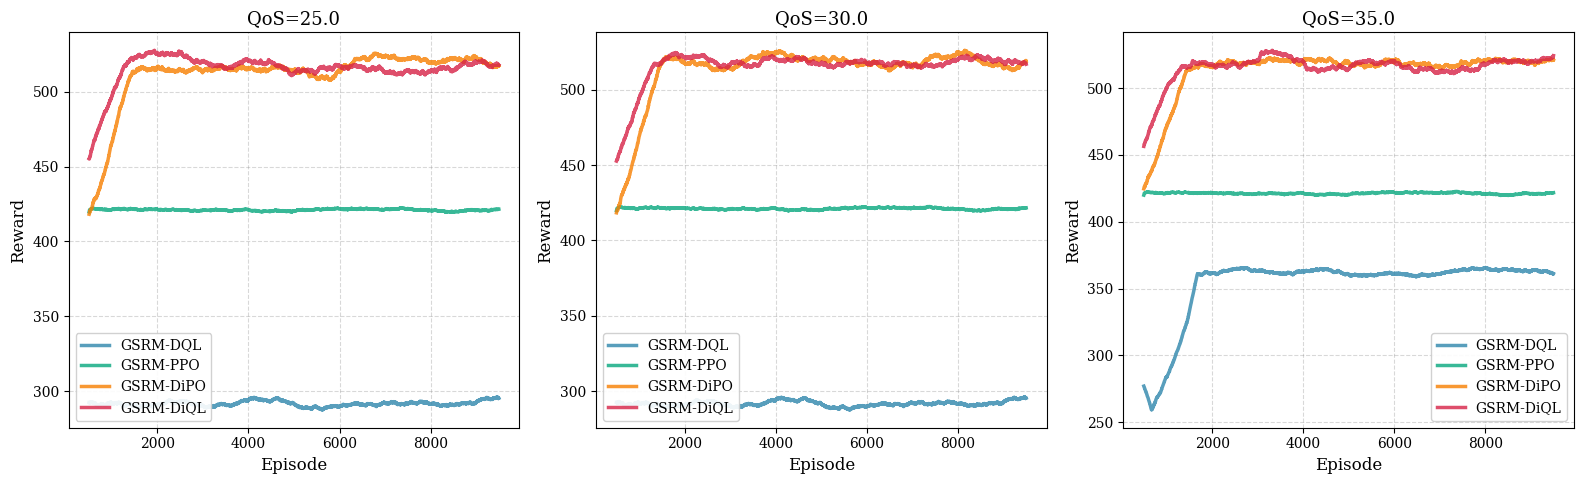

Training convergence plot saved as 'training_convergence_comparison_8.png'


In [21]:
# Comparison plots using training metrics
# 1. Reward vs QoS for fixed user count
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
USER_COUNT = 8

for idx, qos_idx in enumerate([25.0, 30.0, 35.0]):
    ax = axes[idx]
    
    for agent_name in agent_names_list:
        if qos_idx in all_metrics[agent_name] and USER_COUNT in all_metrics[agent_name][qos_idx]:
            rewards = all_metrics[agent_name][qos_idx][USER_COUNT]['all_rewards']
            color = AGENT_CONFIGS[agent_name]['color']
            # print(agent_name, len(rewards))
            # if agent_name == 'ppo_diffusion':
            #     rewards = rewards[i] + 20
            # Smooth rewards
            window = min(1000, len(rewards)//10)
            smoothed = pd.Series(rewards).rolling(window=window, center=True).mean()
            
            ax.plot(smoothed, label=agent_names_display.get(agent_name, agent_name), color=color, linewidth=2.5, alpha=0.8)
    
    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title(f'QoS={qos_idx}', fontsize=13)
    # ax.set_title(f'QoS={qos_idx}, Users={USER_COUNT}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# plt.suptitle(f'Training Convergence Comparison (Users={USER_COUNT})', fontsize=16)
plt.tight_layout()
plt.savefig(f'training_convergence_comparison_{USER_COUNT}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Training convergence plot saved as 'training_convergence_comparison_{USER_COUNT}.png'")

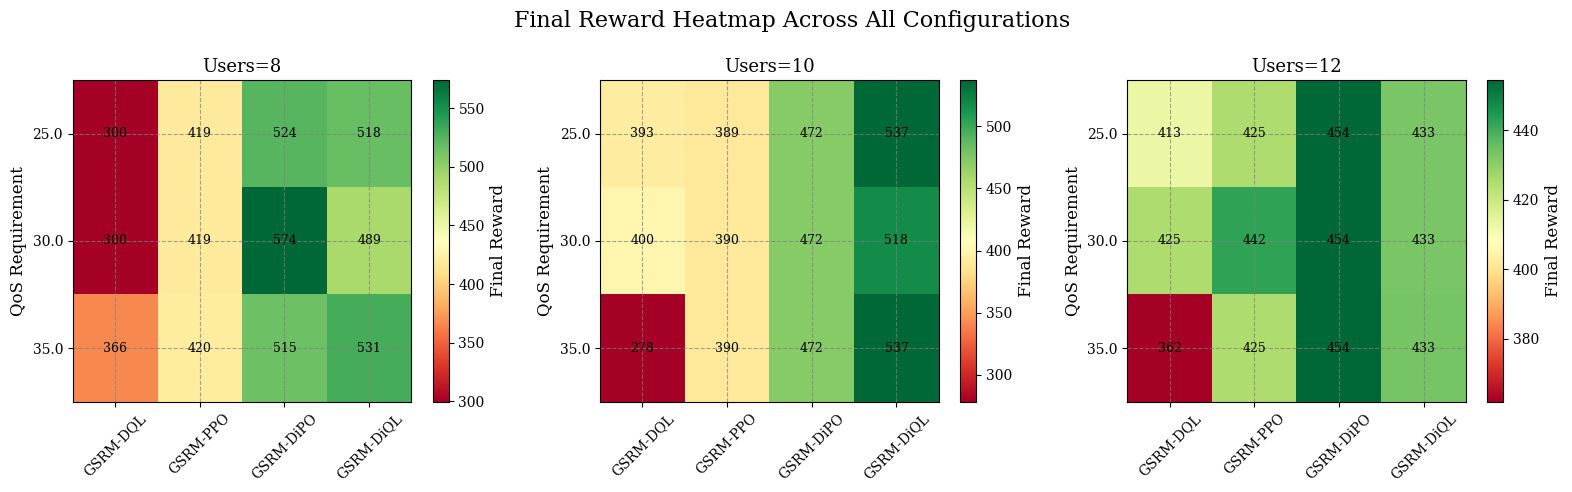

Final reward heatmap saved as 'final_reward_heatmap.png'


In [22]:
# 2. Final Performance Heatmap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, user_count in enumerate([8, 10, 12]):
    ax = axes[idx]
    
    # Prepare data
    data_matrix = []
    for qos in sorted(QOS_VALUES):
        row = []
        for agent_name in agent_names_list:
            if qos in all_metrics[agent_name] and user_count in all_metrics[agent_name][qos]:
                final_reward = all_metrics[agent_name][qos][user_count]['final_reward']
                row.append(final_reward)
            else:
                row.append(0)
        data_matrix.append(row)
    
    # Create heatmap
    im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto')
    # save the heatmap data for debugging
    np.savetxt(f'heatmap_data_users_{user_count}.csv', data_matrix, delimiter=',')
    # Set ticks and labels
    ax.set_xticks(range(len(agent_names_list)))
    ax.set_yticks(range(len(QOS_VALUES)))
    ax.set_xticklabels([agent_names_display.get(a, a) for a in agent_names_list], rotation=45)
    ax.set_yticklabels([f'{q}' for q in sorted(QOS_VALUES)])
    ax.set_ylabel('QoS Requirement')
    ax.set_title(f'Users={user_count}', fontsize=13)
    
    # Add text annotations
    for i, qos in enumerate(sorted(QOS_VALUES)):
        for j, agent_name in enumerate(agent_names_list):
            if qos in all_metrics[agent_name] and user_count in all_metrics[agent_name][qos]:
                value = all_metrics[agent_name][qos][user_count]['final_reward']
                ax.text(j, i, f'{value:.0f}', ha='center', va='center', 
                       color='white' if abs(value) > 100000 else 'black', fontsize=9)
    
    plt.colorbar(im, ax=ax, label='Final Reward')

plt.suptitle('Final Reward Heatmap Across All Configurations', fontsize=16)
plt.tight_layout()
plt.savefig('final_reward_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final reward heatmap saved as 'final_reward_heatmap.png'")


In [23]:
# 3. Agent Ranking Summary
print("\n" + "="*100)
print("AGENT PERFORMANCE SUMMARY - FINAL REWARDS")
print("="*100)

summary_table = []
for agent_name in agent_names_list:
    all_finals = []
    for qos in QOS_VALUES:
        for user in USER_COUNTS:
            if qos in all_metrics[agent_name] and user in all_metrics[agent_name][qos]:
                all_finals.append(all_metrics[agent_name][qos][user]['final_reward'])
    
    if all_finals:
        summary_table.append({
            'Agent': agent_names_display.get(agent_name, agent_name),
            'Best': f"{max(all_finals):.2f}",
            'Worst': f"{min(all_finals):.2f}",
            'Mean': f"{np.mean(all_finals):.2f}",
            'Std': f"{np.std(all_finals):.2f}",
            'Count': len(all_finals),
        })

df_summary = pd.DataFrame(summary_table)
print(df_summary.to_string(index=False))
print("="*100)

# Best configuration per agent
print("\nBEST CONFIGURATION PER AGENT:")
for agent_name in agent_names_list:
    best_reward = -float('inf')
    best_config = None
    
    for qos in QOS_VALUES:
        for user in USER_COUNTS:
            if qos in all_metrics[agent_name] and user in all_metrics[agent_name][qos]:
                reward = all_metrics[agent_name][qos][user]['final_reward']
                if reward > best_reward:
                    best_reward = reward
                    best_config = (qos, user)
    
    if best_config:
        print(f"  {agent_names_display.get(agent_name, agent_name):20s}: QoS={best_config[0]}, Users={best_config[1]}, Reward={best_reward:.2f}")

print("="*100)



AGENT PERFORMANCE SUMMARY - FINAL REWARDS
    Agent   Best  Worst   Mean   Std  Count
 GSRM-DQL 424.96 278.33 359.61 51.29      9
 GSRM-PPO 442.44 389.47 413.29 18.02      9
GSRM-DiPO 573.82 454.12 487.97 38.85      9
GSRM-DiQL 537.04 432.96 492.02 43.77      9

BEST CONFIGURATION PER AGENT:
  GSRM-DQL            : QoS=30.0, Users=12, Reward=424.96
  GSRM-PPO            : QoS=30.0, Users=12, Reward=442.44
  GSRM-DiPO           : QoS=30.0, Users=8, Reward=573.82
  GSRM-DiQL           : QoS=35.0, Users=10, Reward=537.04


# Revenue Tracking over Time in GAI Service Environment

This notebook demonstrates how revenue changes over timesteps during a single episode run.

In [24]:
# Create custom config with step_size = 0.5s and sys_tau = 5s
config = EnvConfig_v1("GAIServiceEnv")

# Modify config for this experiment
config["step_size"] = 0.5  # 0.5s timestep
config["sys_tau"] = 5.0    # 5s total time
config["T"] = int(config["sys_tau"] / config["step_size"])  # 10 steps

print(f"Configuration:")
print(f"  System time (tau): {config['sys_tau']}s")
print(f"  Step size: {config['step_size']}s")
print(f"  Total steps (T): {config['T']}")
print(f"  Number of users: {config['num_users']}")

Configuration:
  System time (tau): 5.0s
  Step size: 0.5s
  Total steps (T): 10
  Number of users: 10


In [25]:
# Initialize environment
env = GAIServiceEnv_v1(config, seed=42)

# Track metrics over time
timesteps = [0.0]  # Start at t=0
revenues = [0.0]   # Initial revenue is 0
rewards = [0.0]    # Initial reward is 0
current_memory = [0.0]  # Current memory (increases when serving, decreases when completing)
peak_memory = [0.0]  # Peak memory usage
users_served = [0]  # Initial users served is 0
latency = [0.0]      # Latency per step

# NEW: Track detailed memory events
memory_events = []  # List of tuples: (time, event_type, user_id, memory_delta, new_current_memory, new_peak_memory)

# Reset environment
state = env.reset()
print(f"\n{'='*80}")
print("Starting episode simulation...")
print(f"{'='*80}\n")

# Run episode
done = False
step = 0

while not done:
    # Take random action
    action = env.action_space.sample()
    
    # Step environment
    observation, reward, done, info = env.step(action)
    step += 1
    
    # Record metrics
    current_time = info.get('current_time', step * config['step_size'])
    timesteps.append(current_time)
    revenues.append(info['total_revenue'])
    rewards.append(info['reward'])
    current_memory.append(env.current_memory_usage)
    peak_memory.append(info['peaked_mem'])
    users_served.append(info['total_users_served'])
    latency.append(info.get('mean_latency', 0.0))
    print(f"Step {step} (t={current_time:.1f}s):")
    print(f"  Revenue: ${revenues[-1]:.4f}")
    print(f"  Current Memory: {env.current_memory_usage:.2f}/{config['Mmax']} GB")
    print(f"  Peak Memory: {peak_memory[-1]:.2f}/{config['Mmax']} GB")
    print(f"  Users served: {users_served[-1]}/{config['num_users']}")
    print(f"  Latency: {latency[-1]:.4f} seconds")
    print()

print(f"{'='*80}")
print("Episode completed!")
print(f"{'='*80}")
print(f"Final statistics:")
print(f"  Total revenue: ${revenues[-1]:.4f}")
print(f"  Total reward: {rewards[-1]:.2f}")
print(f"  Users served: {users_served[-1]}/{config['num_users']}")
print(f"  Peak memory usage: {peak_memory[-1]:.2f}/{config['Mmax']}")
print(f"  Final memory usage: {current_memory[-1]:.2f}/{config['Mmax']}")
print(f"  Average latency: {sum(latency)/len(latency) if latency else 0.0:.4f} seconds")


Starting episode simulation...

Step 1 (t=0.5s):
  Revenue: $29.6012
  Current Memory: 45.57/48 GB
  Peak Memory: 45.57/48 GB
  Users served: 5/10
  Latency: 2.7742 seconds

Step 2 (t=1.0s):
  Revenue: $29.6012
  Current Memory: 45.57/48 GB
  Peak Memory: 45.57/48 GB
  Users served: 5/10
  Latency: 2.7669 seconds

Step 3 (t=1.5s):
  Revenue: $29.6012
  Current Memory: 45.57/48 GB
  Peak Memory: 45.57/48 GB
  Users served: 5/10
  Latency: 2.7669 seconds

Step 4 (t=2.0s):
  Revenue: $37.9040
  Current Memory: 39.51/48 GB
  Peak Memory: 45.57/48 GB
  Users served: 6/10
  Latency: 2.7669 seconds

Step 5 (t=2.5s):
  Revenue: $49.6390
  Current Memory: 42.71/48 GB
  Peak Memory: 45.57/48 GB
  Users served: 7/10
  Latency: 2.7606 seconds

Step 6 (t=3.0s):
  Revenue: $49.6390
  Current Memory: 42.71/48 GB
  Peak Memory: 45.57/48 GB
  Users served: 7/10
  Latency: 2.7616 seconds

Step 7 (t=3.5s):
  Revenue: $71.1376
  Current Memory: 44.58/48 GB
  Peak Memory: 45.57/48 GB
  Users served: 9/10


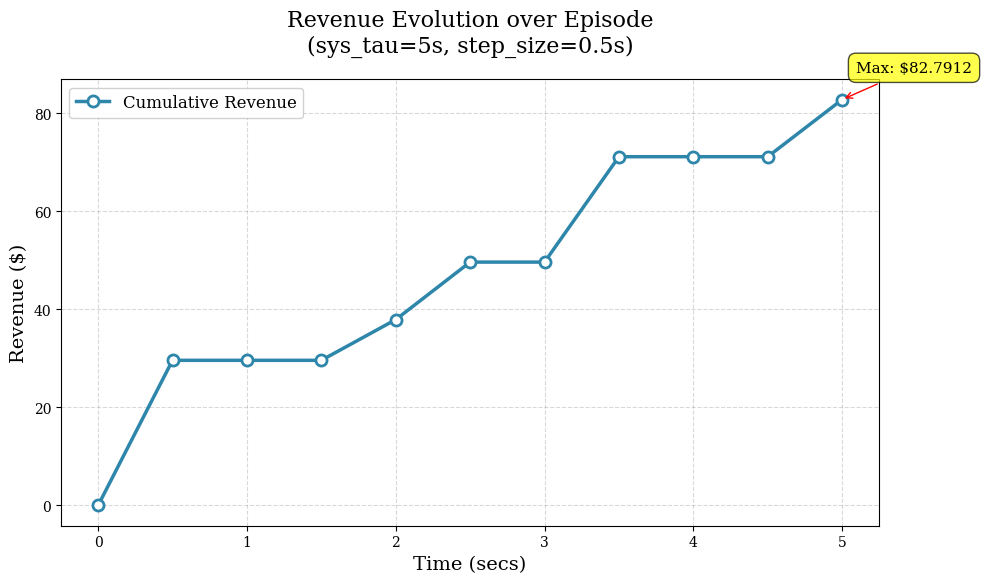


Plot saved as 'revenue_over_time.png'


In [26]:
# Plot Revenue over Time
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(timesteps, revenues, 'o-', color='#2E86AB', linewidth=2.5, 
        markersize=8, label='Cumulative Revenue', markerfacecolor='white', 
        markeredgewidth=2, markeredgecolor='#2E86AB')

ax.set_xlabel('Time (secs)', fontsize=14)
ax.set_ylabel('Revenue ($)', fontsize=14)
ax.set_title('Revenue Evolution over Episode\n(sys_tau=5s, step_size=0.5s)', 
             fontsize=16,  pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=12, loc='upper left')

# Add annotations for key points
max_revenue_idx = np.argmax(revenues)
ax.annotate(f'Max: ${revenues[max_revenue_idx]:.4f}',
            xy=(timesteps[max_revenue_idx], revenues[max_revenue_idx]),
            xytext=(10, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='red'),
            fontsize=11)

plt.tight_layout()
plt.savefig('revenue_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPlot saved as 'revenue_over_time.png'")

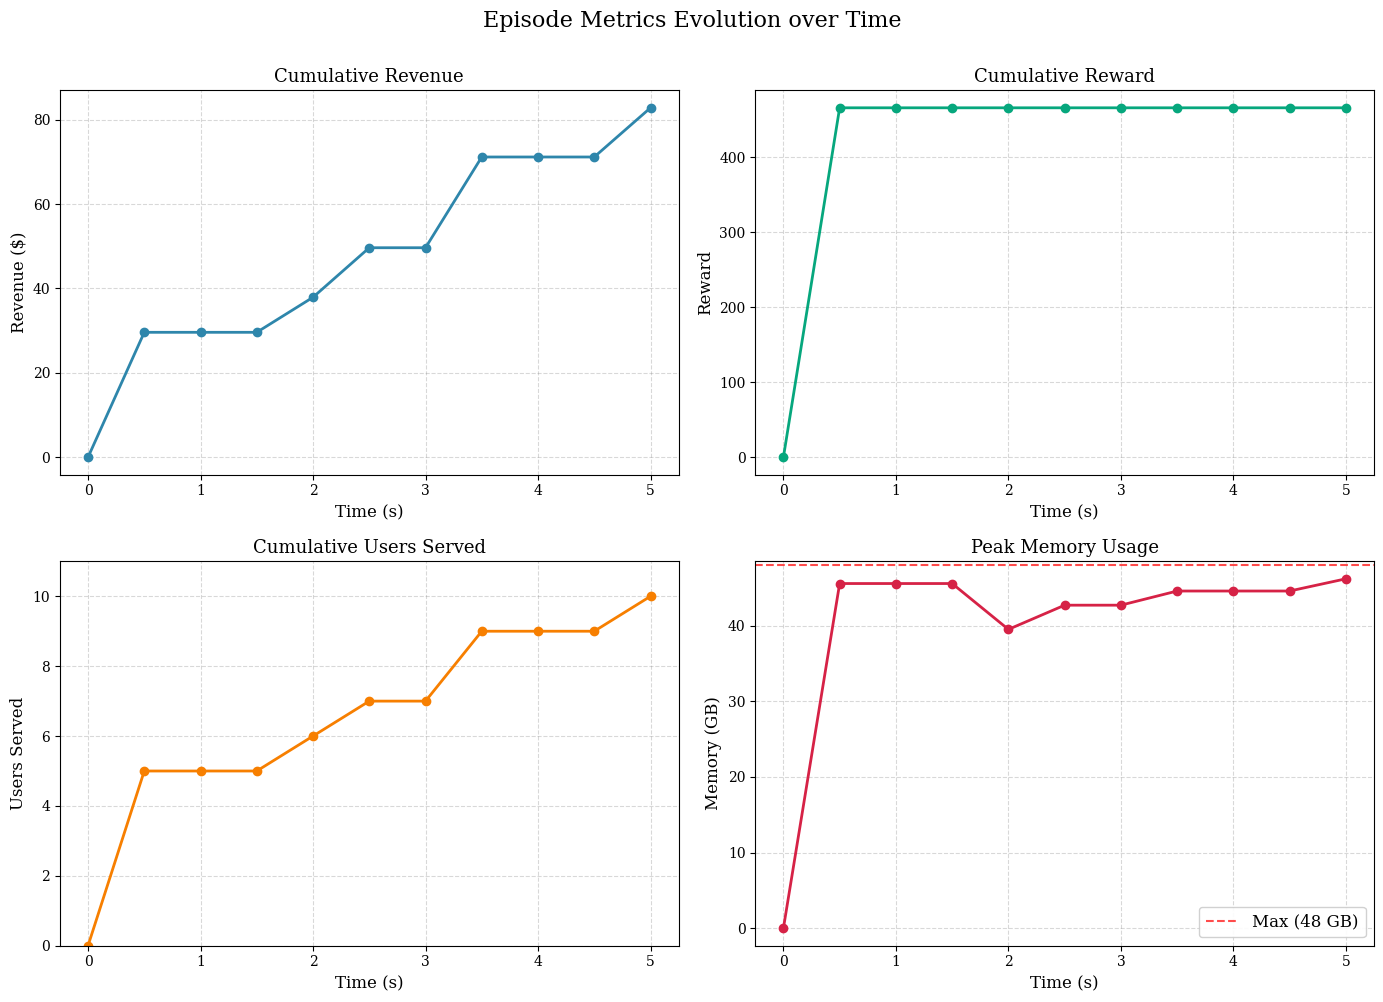


Dashboard saved as 'episode_metrics_dashboard.png'


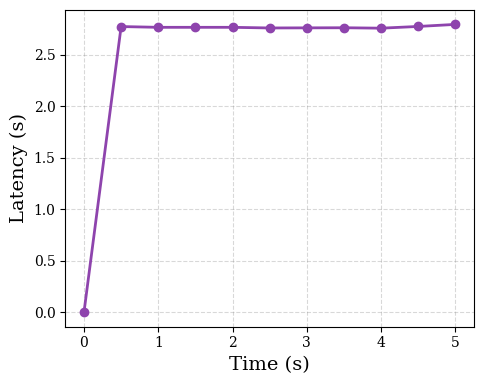

In [27]:
# Plot additional metrics in subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Revenue
axes[0, 0].plot(timesteps, revenues, 'o-', color='#2E86AB', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].set_title('Cumulative Revenue', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)

# 2. Reward
axes[0, 1].plot(timesteps, rewards, 'o-', color='#06A77D', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Reward')
axes[0, 1].set_title('Cumulative Reward', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# 3. Users Served
axes[1, 0].plot(timesteps, users_served, 'o-', color='#F77F00', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Users Served')
axes[1, 0].set_title('Cumulative Users Served', fontsize=13)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, config['num_users'] + 1)

# 4. Peak Memory Usage
axes[1, 1].plot(timesteps, current_memory, 'o-', color='#D62246', linewidth=2, markersize=6)
axes[1, 1].axhline(y=config['Mmax'], color='red', linestyle='--', linewidth=1.5, 
                   label=f"Max ({config['Mmax']} GB)", alpha=0.7)
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Memory (GB)')
axes[1, 1].set_title('Peak Memory Usage', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.suptitle('Episode Metrics Evolution over Time', fontsize=16,  y=1.00)
plt.tight_layout()
plt.savefig('episode_metrics_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDashboard saved as 'episode_metrics_dashboard.png'")

plt.plot(timesteps, latency, 'o-', color='#8E44AD', linewidth=2, markersize=6)
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Latency (s)', fontsize=14)
# plt.title('Latency over Time during Episode\n(sys_tau=5s, step_size=0.5s)', fontsize=16, pad=20)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('latency_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Calculate and display step-by-step revenue increments
revenue_increments = [revenues[i] - revenues[i-1] for i in range(1, len(revenues))]

print("\n" + "="*70)
print("STEP-BY-STEP REVENUE ANALYSIS")
print("="*70)
print(f"{'Step':<6} {'Time(s)':<10} {'Revenue Δ':<15} {'Cumulative':<15}")
print("-"*70)

for i in range(len(revenue_increments)):
    print(f"{i+1:<6} {timesteps[i+1]:<10.1f} ${revenue_increments[i]:<14.4f} ${revenues[i+1]:<14.4f}")

print("="*70)
print(f"Total Revenue Generated: ${revenues[-1]:.4f}")
print(f"Average Revenue per Step: ${np.mean(revenue_increments):.4f}")
print(f"Max Single-Step Revenue: ${np.max(revenue_increments):.4f} (Step {np.argmax(revenue_increments)+1})")
print(f"Min Single-Step Revenue: ${np.min(revenue_increments):.4f} (Step {np.argmin(revenue_increments)+1})")
print("="*70)


STEP-BY-STEP REVENUE ANALYSIS
Step   Time(s)    Revenue Δ       Cumulative     
----------------------------------------------------------------------
1      0.5        $29.6012        $29.6012       
2      1.0        $0.0000         $29.6012       
3      1.5        $0.0000         $29.6012       
4      2.0        $8.3028         $37.9040       
5      2.5        $11.7350        $49.6390       
6      3.0        $0.0000         $49.6390       
7      3.5        $21.4986        $71.1376       
8      4.0        $0.0000         $71.1376       
9      4.5        $0.0000         $71.1376       
10     5.0        $11.6535        $82.7912       
Total Revenue Generated: $82.7912
Average Revenue per Step: $8.2791
Max Single-Step Revenue: $29.6012 (Step 1)
Min Single-Step Revenue: $0.0000 (Step 2)


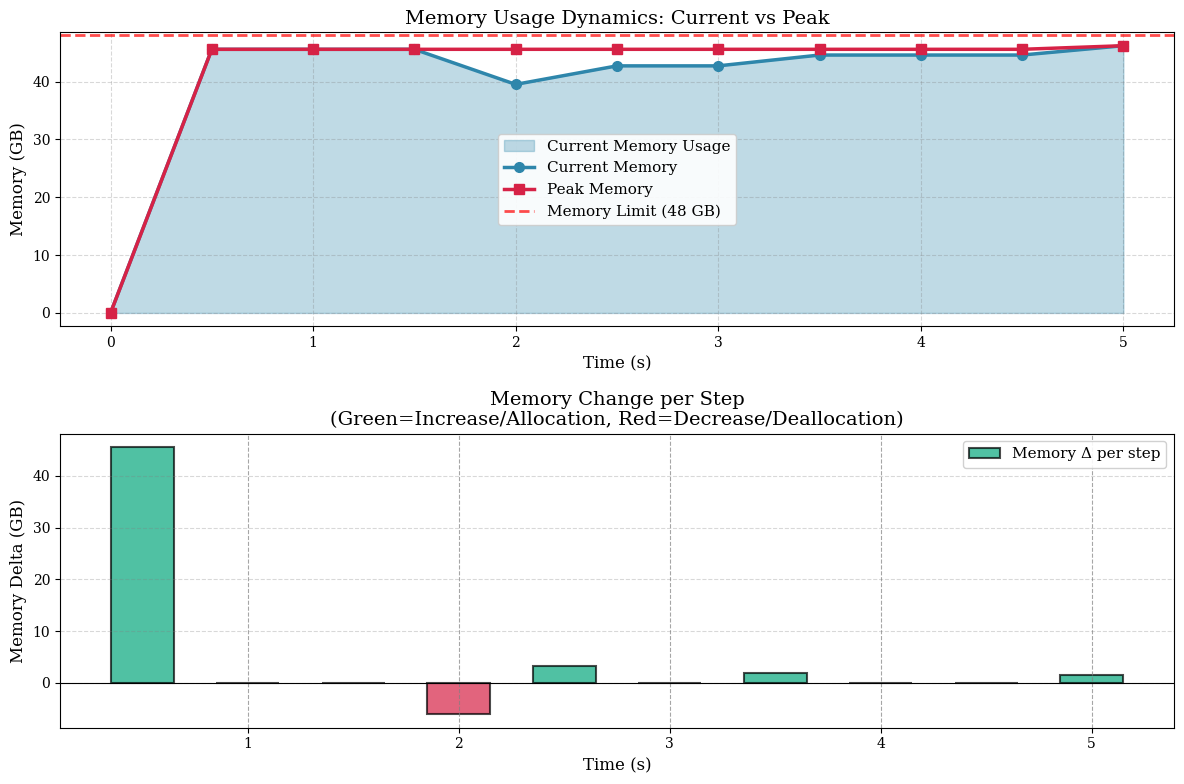

Memory dynamics plot saved as 'memory_dynamics.png'


In [29]:
# Plot Memory Dynamics (Current vs Peak)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Current Memory vs Peak Memory
ax1.fill_between(timesteps, 0, current_memory, alpha=0.3, color='#2E86AB', 
                 label='Current Memory Usage')
ax1.plot(timesteps, current_memory, 'o-', color='#2E86AB', linewidth=2.5, 
         markersize=7, label='Current Memory')
ax1.plot(timesteps, peak_memory, 's-', color='#D62246', linewidth=2.5, 
         markersize=7, label='Peak Memory')
ax1.axhline(y=config['Mmax'], color='red', linestyle='--', linewidth=2, 
            label=f'Memory Limit ({config["Mmax"]} GB)', alpha=0.7)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Memory (GB)', fontsize=12)
ax1.set_title('Memory Usage Dynamics: Current vs Peak', fontsize=14)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='best')

# Plot 2: Memory Delta (change per step)
memory_delta = [current_memory[i] - current_memory[i-1] for i in range(1, len(current_memory))]
colors_delta = ['#06A77D' if delta >= 0 else '#D62246' for delta in memory_delta]

ax2.bar(timesteps[1:], memory_delta, width=0.3, color=colors_delta, alpha=0.7, 
        edgecolor='black', linewidth=1.5, label='Memory Δ per step')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Memory Delta (GB)', fontsize=12)
ax2.set_title('Memory Change per Step\n(Green=Increase/Allocation, Red=Decrease/Deallocation)', 
              fontsize=14)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('memory_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Memory dynamics plot saved as 'memory_dynamics.png'")


In [30]:
# Detailed Memory Analysis
print("\n" + "="*100)
print("DETAILED MEMORY DYNAMICS ANALYSIS")
print("="*100)
print(f"{'Step':<6} {'Time(s)':<10} {'Current Mem':<15} {'Peak Mem':<15} {'Δ Memory':<15} {'Users':<8}")
print("-"*100)

for i in range(len(timesteps)):
    if i == 0:
        delta = 0.0
        users = 0
    else:
        delta = current_memory[i] - current_memory[i-1]
        users = users_served[i]
    
    delta_str = f"{delta:+.2f}"
    if delta > 0:
        delta_str = "🔴 " + delta_str + " (allocate)"
    elif delta < 0:
        delta_str = "🟢 " + delta_str + " (free)"
    else:
        delta_str = "⚪ " + delta_str + " (no change)"
    
    print(f"{i:<6} {timesteps[i]:<10.1f} {current_memory[i]:<14.2f} {peak_memory[i]:<14.2f} {delta_str:<15} {users:<8}")

print("="*100)

# Summary statistics
print(f"\nMEMORY SUMMARY:")
print(f"  Initial memory: {current_memory[0]:.2f} GB")
print(f"  Final memory: {current_memory[-1]:.2f} GB")
print(f"  Peak memory reached: {max(peak_memory):.2f} GB")
print(f"  Memory limit: {config['Mmax']} GB")
print(f"  Peak utilization: {max(peak_memory)/config['Mmax']*100:.1f}%")
print(f"  Final utilization: {current_memory[-1]/config['Mmax']*100:.1f}%")

# Memory events analysis
total_allocated = sum([delta for delta in memory_delta if delta > 0])
total_freed = sum([abs(delta) for delta in memory_delta if delta < 0])

print(f"\nMEMORY EVENTS:")
print(f"  Total memory allocated: {total_allocated:.2f} GB")
print(f"  Total memory freed: {total_freed:.2f} GB")
print(f"  Net memory change: {current_memory[-1] - current_memory[0]:+.2f} GB")
print(f"  Steps with allocation: {sum([1 for delta in memory_delta if delta > 0])}")
print(f"  Steps with deallocation: {sum([1 for delta in memory_delta if delta < 0])}")
print(f"  Steps with no change: {sum([1 for delta in memory_delta if delta == 0])}")
print("="*100)



DETAILED MEMORY DYNAMICS ANALYSIS
Step   Time(s)    Current Mem     Peak Mem        Δ Memory        Users   
----------------------------------------------------------------------------------------------------
0      0.0        0.00           0.00           ⚪ +0.00 (no change) 0       
1      0.5        45.57          45.57          🔴 +45.57 (allocate) 5       
2      1.0        45.57          45.57          ⚪ +0.00 (no change) 5       
3      1.5        45.57          45.57          ⚪ +0.00 (no change) 5       
4      2.0        39.51          45.57          🟢 -6.06 (free)  6       
5      2.5        42.71          45.57          🔴 +3.20 (allocate) 7       
6      3.0        42.71          45.57          ⚪ +0.00 (no change) 7       
7      3.5        44.58          45.57          🔴 +1.87 (allocate) 9       
8      4.0        44.58          45.57          ⚪ +0.00 (no change) 9       
9      4.5        44.58          45.57          ⚪ +0.00 (no change) 9       
10     5.0        46.20  

Loading metrics from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_25.0_users_8.json
Loading metrics from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_25.0_users_10.json
Loading metrics from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_25.0_users_12.json
Loading metrics from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_30.0_users_8.json
Loading metrics from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_30.0_users_10.json
Loading metrics from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_30.0_users_12.json
Loading metrics from: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/25/gaussian_dql/training_metrics_qos_35.0_users_8.json
Lo

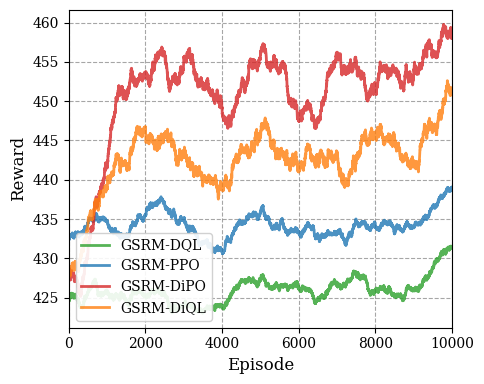

In [31]:

from pathlib import Path
import json
seed = 25
logs_dir = Path(f"/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}")
qos_required = [25.0, 30.0, 35.0]
num_users = [8, 10, 12]
# Collect data from all training runs
training_data = {}

for folder in sorted(logs_dir.iterdir()):

    for i in range(len(qos_required)):
        for j in range(len(num_users)):
            if folder.name not in training_data:
                training_data[folder.name] = {}
            if str(qos_required[i]) not in training_data[folder.name]:
                training_data[folder.name][str(qos_required[i])] = {}
            if str(num_users[j]) not in training_data[folder.name][str(qos_required[i])]:
                training_data[folder.name][str(qos_required[i])][str(num_users[j])] = {}
            if folder.is_dir():
                metrics_file = folder / f"training_metrics_qos_{float(qos_required[i])}_users_{num_users[j]}.json"
                print(f"Loading metrics from: {metrics_file}")
                if metrics_file.exists():
                    with open(metrics_file, 'r') as f:
                        data = json.load(f)
                        if "episode_rewards" in data:
                            training_data[folder.name][str(qos_required[i])][str(num_users[j])] = data["episode_rewards"]
                            # print(f"✓ Loaded {folder.name}: {len(data['episode_rewards'])} episodes")
                        else:
                            print(f"✗ No episode_rewards in {folder.name}")
                            # pass
                    
import matplotlib.pyplot as plt

def smooth_rewards(rewards, window=200):
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(rewards, size=window)


training_data.keys()

# extracted_keys = ["ql_diffusion", "ppo_diffusion"]
# training_data = {k: training_data[k] for k in extracted_keys if k in training_data}


# colors = {
#     'ppo_diffusion': 'tab:red',
#     'ql_diffusion': 'tab:orange',
#     'gaussian_ppo': 'tab:blue',
#     'gaussian_dql': 'tab:green',
# }


# # Plot training rewards for all algorithms
# plt.figure(figsize=(8, 6))
# for alg_name, rewards in training_data.items():
#     plt.plot(smooth_rewards(rewards), label=get_algorithm_display_name(alg_name), color=colors.get(alg_name, 'black'), alpha=0.8)
# plt.xlabel('Episode')
# plt.ylabel('Reward')
# # plt.title(f'Training Rewards (QoS={qos_required}, Users={num_users})')
# plt.xlim(0, 10000)
# plt.legend()
# plt.grid(True)
# plt.grid(True)
# plt.tight_layout()
# plt.savefig('training_rewards_comparison.png', dpi=300)


colors = {
     'ql_diffusion': {
        '25.0': {'8': '#B8860B',    # darkgoldenrod (tối)
               '10': '#FFD700',      # gold (vừa)
               '12': '#FFFFE0'},     # lightyellow (sáng)
        '30.0': {'8': '#DAA520',    # goldenrod
               '10': '#F0E68C',      # khaki
               '12': '#FFFACD'},     # lemonchiffon
        '35.0': {'8': '#BDB76B',    # darkkhaki
               '10': '#EEE8AA',      # palegoldenrod
               '12': '#FAFAD2'},     # lightgoldenrodyellow
    },
    'ppo_diffusion': {
        '25.0': {'8': '#8B0000',    # darkred (tối)
               '10': '#DC143C',      # crimson (vừa)
               '12': '#FFB6C1'},     # lightpink (sáng)
        '30.0': {'8': '#B22222',    # firebrick
               '10': '#FF0000',      # red
               '12': '#FFA07A'},     # lightsalmon
        '35.0': {'8': '#CD5C5C',    # indianred
               '10': '#FF6347',      # tomato
               '12': '#F08080'},     # lightcoral
    },
    'gaussian_ppo': {
        '25.0': {'8': '#00008B',    # darkblue (tối)
               '10': '#4169E1',      # royalblue (vừa)
               '12': '#87CEEB'},     # skyblue (sáng)
        '30.0': {'8': '#0000CD',    # mediumblue
               '10': '#1E90FF',      # dodgerblue
               '12': '#87CEFA'},     # lightskyblue
        '35.0': {'8': '#4682B4',    # steelblue
               '10': '#00BFFF',      # deepskyblue
               '12': '#B0E0E6'},     # powderblue
    },
    'gaussian_dql': {
        '25.0': {'8': '#006400',    # darkgreen (tối)
               '10': '#32CD32',      # limegreen (vừa)
               '12': '#90EE90'},     # lightgreen (sáng)
        '30.0': {'8': '#228B22',    # forestgreen
               '10': '#00FF00',      # lime
               '12': '#98FB98'},     # palegreen
        '35.0': {'8': '#2E8B57',    # seagreen
               '10': '#00FA9A',      # mediumspringgreen
               '12': '#AFEEEE'},     # paleturquoise
    },
}

def plotting_reward(training_data, qos = [30.0], users = [8, 10, 12], is_out=False, colors = colors, window = 1000):
    plt.figure(figsize=(5, 4))
    for i in range(len(qos)):
        for j in range(len(users)):
            for alg_name in training_data.keys():
                label = f"{get_algorithm_display_name(alg_name)}"
                rewards =  training_data[alg_name][str(qos[i])][str((users[j]))]
                if alg_name == "ppo_diffusion":
                    rewards = [rewards[k]+10 for k in range(len(rewards))] 
                plt.plot(smooth_rewards(rewards, window), 
                         label=label, color=colors[alg_name][str(qos[i])][str(users[j])], alpha=0.8)
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.xlim(0, 10000)
    if is_out:
        plt.legend(fontsize=10, loc='center left', bbox_to_anchor=(1, 0.5)) # set legend outside
    else:
        plt.legend(fontsize=10, loc='lower left')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'compare.png', dpi=300)
    

colors = {
     'ql_diffusion': {
        '25.0': {'8': '#B8860B',    # darkgoldenrod (tối)
               '10': '#FFD700',      # gold (vừa)
               '12': 'tab:orange'},     # lightyellow (sáng)
        '30.0': {'8': '#DAA520',    # goldenrod
               '10': '#F0E68C',      # khaki
               '12': '#FFFACD'},     # lemonchiffon
        '35.0': {'8': '#BDB76B',    # darkkhaki
               '10': '#EEE8AA',      # palegoldenrod
               '12': '#FAFAD2'},     # lightgoldenrodyellow
    },
    'ppo_diffusion': {
        '25.0': {'8': '#8B0000',    # darkred (tối)
               '10': '#DC143C',      # crimson (vừa)
               '12': 'tab:red'},     # lightpink (sáng)
        '30.0': {'8': '#B22222',    # firebrick
               '10': '#FF0000',      # red
               '12': '#FFA07A'},     # lightsalmon
        '35.0': {'8': '#CD5C5C',    # indianred
               '10': '#FF6347',      # tomato
               '12': '#F08080'},     # lightcoral
    },
    'gaussian_ppo': {
        '25.0': {'8': '#00008B',    # darkblue (tối)
               '10': '#4169E1',      # royalblue (vừa)
               '12': 'tab:blue'},     # skyblue (sáng)
        '30.0': {'8': '#0000CD',    # mediumblue
               '10': '#1E90FF',      # dodgerblue
               '12': '#87CEFA'},     # lightskyblue
        '35.0': {'8': '#4682B4',    # steelblue
               '10': '#00BFFF',      # deepskyblue
               '12': '#B0E0E6'},     # powderblue
    },
    'gaussian_dql': {
        '25.0': {'8': '#006400',    # darkgreen (tối)
               '10': '#32CD32',      # limegreen (vừa)
               '12': 'tab:green'},     # lightgreen (sáng)
        '30.0': {'8': '#228B22',    # forestgreen
               '10': '#00FF00',      # lime
               '12': '#98FB98'},     # palegreen
        '35.0': {'8': '#2E8B57',    # seagreen
               '10': '#00FA9A',      # mediumspringgreen
               '12': '#AFEEEE'},     # paleturquoise
    },
}
plotting_reward(training_data, [25.0], [12], False, colors)

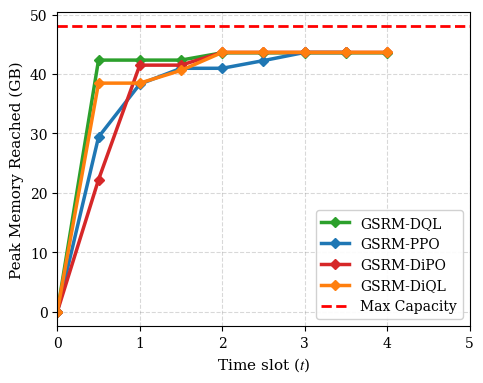

✓ Comparison plots saved as 'agent_dynamics_comparison.png'


In [32]:
# Create comparison plots for agent dynamics
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Define colors for agents
agent_colors = COLOR_SCHEME_1 

agent_names_display = {
    'gaussian_dql': 'GSRM-DQL',
    'gaussian_ppo': 'GSRM-PPO',
    'ppo_diffusion': 'GSRM-DiPO',
    'ql_diffusion': 'GSRM-DiQL'
}

# Helper function to fill missing values with 0
def fill_missing_values(timesteps, values):
    """Fill missing values in the list with 0, ensuring same length as timesteps"""
    if len(values) < len(timesteps):
        filled_values = values + [0] * (len(timesteps) - len(values))
        return filled_values
    return values[:len(timesteps)]

# Create figure with 2x2 subplots for the 4 key metrics
# gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.3)

if os.path.exists('cumulative') is False:
    os.makedirs('cumulative')

# 1. Cumulative Revenue over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    revenues_filled = fill_missing_values(metrics['timesteps'], metrics['revenues'])
    plt.plot(
        metrics['timesteps'], 
        revenues_filled,
        marker='o',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel(r'Revenue ($\vartheta_t$)', fontsize=11)
# plt.title('Cumulative Revenue Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.legend(fontsize=10)
plt.savefig(f'cumulative/cumulative_revenue_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 2. Cumulative Users Served over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    users_served_filled = fill_missing_values(metrics['timesteps'], metrics['users_served'])
    plt.plot(
        metrics['timesteps'],
        users_served_filled,
        marker='s',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel('Number of users ($N_t$)', fontsize=11)
# plt.title('Cumulative Users Served Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.yticks(range(0, TEST_ENV_CONFIG['num_users']+1))
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.axhline(y=TEST_ENV_CONFIG['num_users'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.legend(fontsize=10)
plt.savefig(f'cumulative/cumulative_users_served_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 3. Current Memory Usage over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    current_memory_filled = fill_missing_values(metrics['timesteps'], metrics['current_memory'])
    plt.plot(
        metrics['timesteps'],
        current_memory_filled,
        marker='^',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel('Memory Usage ($m_t$)', fontsize=11)
# plt.title('Current Memory Usage Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau'])
plt.axhline(y=TEST_ENV_CONFIG['Mmax'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.legend(fontsize=10)
plt.savefig(f'cumulative/current_memory_usage_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
plt.close()

# 4. Peak Memory Reached over Time
for agent_name in agent_dynamics.keys():
    metrics = agent_dynamics[agent_name]
    peak_memory_filled = fill_missing_values(metrics['timesteps'], metrics['peak_memory'])
    plt.plot(
        metrics['timesteps'],
        peak_memory_filled,
        marker='D',
        linewidth=2.5,
        markersize=5,
        label=agent_names_display[agent_name],
        color=agent_colors.get(agent_name, '#000000')
    )
plt.xlabel('Time slot ($t$)', fontsize=11)
plt.ylabel('Peak Memory Reached (GB)', fontsize=11)
# plt.title('Peak Memory Usage Over Time', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=TEST_ENV_CONFIG['Mmax'], color='red', linestyle='--', linewidth=2, label='Max Capacity')
plt.xlim(0, TEST_ENV_CONFIG['sys_tau']) 
plt.legend(fontsize=10)
plt.savefig(f'cumulative/peak_memory_usage_comparison_{TEST_ENV_CONFIG["qos_required"]}_{TEST_ENV_CONFIG["num_users"]}_{TEST_ENV_CONFIG["sys_tau"]}.png', dpi=300, bbox_inches='tight')
# plt.close()

# plt.suptitle(f'Agent Dynamics Comparison - Single Episode (QoS={TEST_ENV_CONFIG["qos_required"]}, Users={TEST_ENV_CONFIG["num_users"]}, Duration={TEST_ENV_CONFIG["sys_tau"]}s)', 
            #  fontsize=14,  y=0.995)

plt.tight_layout()
# plt.savefig('agent_dynamics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plots saved as 'agent_dynamics_comparison.png'")